# Phase 03 — Strictly Prior-Date Historical Features

This notebook reads the four Phase 02 model-track datasets and adds auditable historical performance features for the striker, non-striker, bowler, batting team, bowling team, and venue/innings context.

Every history uses matches dated **strictly before** the current match. All matches on the same calendar date are treated as simultaneous: they cannot update one another. This phase does not fit an imputer, encoder, scaler, model, or train/validation/test split.

## Feature and identity policy

- Player identity is the exact source display name within gender. No unsupported name resolution or playing-XI inference is attempted.
- Batting balls faced exclude wides and include no-balls; batting dot balls mean zero runs off the bat on a non-wide event.
- Bowler runs conceded exclude byes, leg-byes, and penalties. Run-outs, obstructing the field, and hit-the-ball-twice dismissals are not credited to the bowler.
- Team history is gender-specific and uses one result per team per match.
- Venue history is gender- and innings-specific because batting-side win prevalence differs by innings.
- Exposure counts are zero for unseen entities. Undefined rates remain null and must only be imputed inside the Phase 04 training split.

In [1]:
from __future__ import annotations

import csv
import gzip
import json
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
from IPython.display import display

PROJECT_ROOT = next(
    (path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (path / 'data' / 'raw').exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Open this notebook inside the project repository.')

INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
PHASE_02_METRICS_PATH = PROJECT_ROOT / 'reports' / 'metrics' / 'phase_02_game_state_features.json'
METRICS_PATH = PROJECT_ROOT / 'reports' / 'metrics' / 'phase_03_historical_features.json'

TRACK_NAMES = [
    'female_innings_1',
    'female_innings_2',
    'male_innings_1',
    'male_innings_2',
]
PHASE_02_PATHS = {
    name: INTERIM_DIR / f'phase_02_{name}.csv.gz' for name in TRACK_NAMES
}
for path in PHASE_02_PATHS.values():
    if not path.exists():
        raise FileNotFoundError(f'Run Phase 02 first; missing {path.name}')

PHASE_02_METRICS = json.loads(PHASE_02_METRICS_PATH.read_text())
PARAMS = yaml.safe_load((PROJECT_ROOT / 'params.yaml').read_text())
HISTORY_CONFIG = PARAMS['features']['historical']
assert HISTORY_CONFIG['date_rule'] == 'strictly_before_match_date'
assert HISTORY_CONFIG['equal_date_rule'] == 'simultaneous'
assert HISTORY_CONFIG['player_identity'] == 'exact_display_name_within_gender'
assert HISTORY_CONFIG['undefined_rate_policy'] == 'null_with_zero_exposure'
assert HISTORY_CONFIG['batting_ball_definition'] == 'non_wide_event'
assert HISTORY_CONFIG['batting_dot_definition'] == 'zero_batter_runs_on_non_wide_event'
assert HISTORY_CONFIG['boundary_ball_definition'] == 'four_or_six_batter_runs_on_non_wide_event'
assert HISTORY_CONFIG['bowler_runs_conceded_exclusions'] == ['byes', 'legbyes', 'penalty']
assert HISTORY_CONFIG['venue_grouping'] == ['gender', 'venue', 'match_innings']
PHASE_02_MODEL_FEATURES = {
    int(innings): columns
    for innings, columns in PHASE_02_METRICS['model_feature_columns_by_innings'].items()
}

BATTER_BASE_FEATURES = [
    'prior_batting_matches',
    'prior_balls_faced',
    'prior_strike_rate',
    'prior_batting_average',
    'prior_boundary_ball_rate',
    'prior_dot_ball_rate',
]
HISTORICAL_MODEL_FEATURES = [
    *[f'striker_{column}' for column in BATTER_BASE_FEATURES],
    *[f'non_striker_{column}' for column in BATTER_BASE_FEATURES],
    'bowler_prior_bowling_matches',
    'bowler_prior_legal_balls',
    'bowler_prior_economy_rate',
    'bowler_prior_bowling_strike_rate',
    'bowler_prior_dot_ball_rate',
    'batting_team_prior_matches',
    'batting_team_prior_win_rate',
    'bowling_team_prior_matches',
    'bowling_team_prior_win_rate',
    'venue_innings_prior_matches',
    'venue_innings_prior_batting_win_rate',
]
COUNT_FEATURES = [
    'striker_prior_batting_matches', 'striker_prior_balls_faced',
    'non_striker_prior_batting_matches', 'non_striker_prior_balls_faced',
    'bowler_prior_bowling_matches', 'bowler_prior_legal_balls',
    'batting_team_prior_matches', 'bowling_team_prior_matches',
    'venue_innings_prior_matches',
]

assert len(HISTORICAL_MODEL_FEATURES) == len(set(HISTORICAL_MODEL_FEATURES)) == 23
print('Phase 02 inputs:')
for name, path in PHASE_02_PATHS.items():
    print(f'  {name}: {path.relative_to(PROJECT_ROOT)}')

Phase 02 inputs:
  female_innings_1: data/interim/phase_02_female_innings_1.csv.gz
  female_innings_2: data/interim/phase_02_female_innings_2.csv.gz
  male_innings_1: data/interim/phase_02_male_innings_1.csv.gz
  male_innings_2: data/interim/phase_02_male_innings_2.csv.gz


### Temporal validity of historical features

For a match on date *d*, only contributions from dates strictly earlier than *d* are visible. Matches sharing date *d* receive the same pre-date history and cannot update one another.

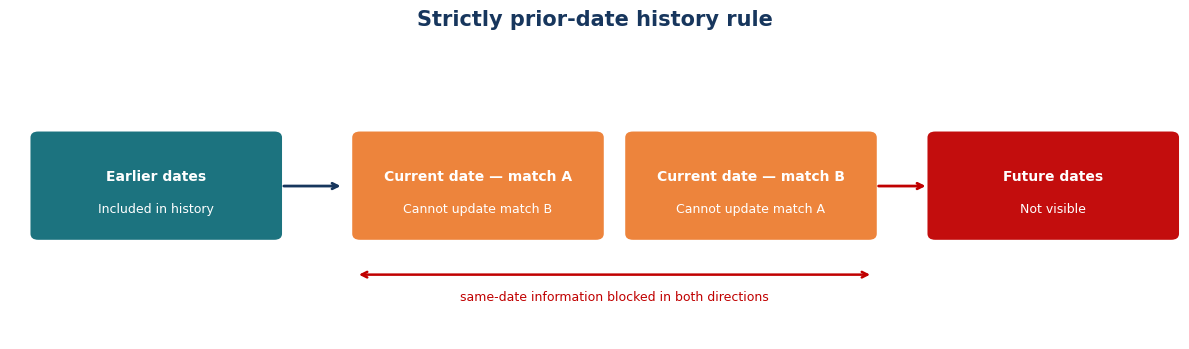

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

NAVY = '#17365D'
TEAL = '#0F6B78'
ORANGE = '#ED7D31'
RED = '#C00000'

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis('off')

positions = [1.5, 4.8, 7.6, 10.7]
labels = [
    ('Earlier dates', 'Included in history', TEAL),
    ('Current date — match A', 'Cannot update match B', ORANGE),
    ('Current date — match B', 'Cannot update match A', ORANGE),
    ('Future dates', 'Not visible', RED),
]
for x, (title, subtitle, color) in zip(positions, labels, strict=True):
    box = FancyBboxPatch(
        (x - 1.25, 1.35), 2.5, 1.35,
        boxstyle='round,pad=0.04,rounding_size=0.08',
        facecolor=color, edgecolor='none', alpha=0.95,
    )
    ax.add_patch(box)
    ax.text(x, 2.15, title, ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    ax.text(x, 1.72, subtitle, ha='center', va='center', color='white', fontsize=9)

ax.annotate('', xy=(3.42, 2.02), xytext=(2.78, 2.02), arrowprops={'arrowstyle': '->', 'color': NAVY, 'lw': 2})
ax.annotate('', xy=(3.55, 0.85), xytext=(8.85, 0.85), arrowprops={'arrowstyle': '<->', 'color': RED, 'lw': 1.8})
ax.text(6.2, 0.52, 'same-date information blocked in both directions', ha='center', color=RED, fontsize=9)
ax.annotate('', xy=(9.42, 2.02), xytext=(8.88, 2.02), arrowprops={'arrowstyle': '->', 'color': RED, 'lw': 2})
ax.set_title('Strictly prior-date history rule', fontsize=15, fontweight='bold', color=NAVY, pad=8)
fig.tight_layout()
plt.show()

## 1. Load the minimum event history source

The four Phase 02 files partition the Phase 01 delivery stream. Only columns required to construct historical aggregates are concatenated here; full track schemas are loaded one at a time when outputs are written.

In [3]:
HISTORY_SOURCE_COLUMNS = [
    'match_id', 'source_row', 'match_date', 'gender', 'match_innings', 'venue',
    'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
    'runs_batter', 'runs_total', 'current_event_wicket', 'player_out', 'wicket_kind',
    'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'legal_delivery',
    'batting_team_win_match',
]
history_frames = []
for name, path in PHASE_02_PATHS.items():
    frame = pd.read_csv(
        path,
        usecols=HISTORY_SOURCE_COLUMNS,
        parse_dates=['match_date'],
        low_memory=False,
    )
    history_frames.append(frame)

events = pd.concat(history_frames, ignore_index=True)
del history_frames
events = events.sort_values('source_row', kind='stable').reset_index(drop=True)

assert len(events) == PHASE_02_METRICS['source']['rows']
assert events['match_id'].nunique() == PHASE_02_METRICS['source']['matches']
assert not events['source_row'].duplicated().any()
assert events[['match_date', 'gender', 'venue', 'batting_team', 'bowling_team',
               'striker', 'non_striker', 'bowler']].notna().all().all()

display(pd.DataFrame([
    {'metric': 'event rows', 'value': len(events)},
    {'metric': 'matches', 'value': events['match_id'].nunique()},
    {'metric': 'match dates', 'value': events['match_date'].nunique()},
    {'metric': 'exact player display names', 'value': pd.unique(
        pd.concat([events['striker'], events['non_striker'], events['bowler']], ignore_index=True)
    ).size},
]))

,metric,value
0,event rows,1156215
1,matches,4975
2,match dates,2136
3,exact player display names,7081


## 2. Build date-batched prior-history lookups

Contributions are first collapsed to one daily row per entity. The current date's full contribution is then subtracted from the cumulative total. This makes the lookup identical for every same-date match and guarantees that only earlier dates are visible.

In [4]:
def add_strict_prior_totals(
    daily: pd.DataFrame,
    entity_keys: list[str],
    additive_columns: list[str],
) -> pd.DataFrame:
    out = daily.sort_values([*entity_keys, 'match_date'], kind='stable').reset_index(drop=True)
    grouped = out.groupby(entity_keys, sort=False, observed=True)
    for column in additive_columns:
        out[f'prior_{column}'] = grouped[column].cumsum() - out[column]
    return out


def safe_rate(numerator: pd.Series, denominator: pd.Series, multiplier: float = 1.0) -> pd.Series:
    return multiplier * numerator / denominator.where(denominator.gt(0))


# Synthetic check: two matches on day two are aggregated before the prior total is calculated.
synthetic_daily = pd.DataFrame({
    'gender': ['female', 'female', 'female'],
    'player': ['A', 'A', 'A'],
    'match_date': pd.to_datetime(['2020-01-01', '2020-01-02', '2020-01-03']),
    'runs': [10, 50, 5],  # day-two value already combines two simultaneous matches
})
synthetic_prior = add_strict_prior_totals(
    synthetic_daily, ['gender', 'player'], ['runs']
)
assert synthetic_prior['prior_runs'].tolist() == [0, 10, 60]


# Batting contributions and participation, including a player who only appears as non-striker.
striker_participants = events[
    ['gender', 'match_id', 'match_date', 'batting_team', 'striker']
].rename(columns={'striker': 'player'})
non_striker_participants = events[
    ['gender', 'match_id', 'match_date', 'batting_team', 'non_striker']
].rename(columns={'non_striker': 'player'})
batting_participants = pd.concat(
    [striker_participants, non_striker_participants], ignore_index=True
).drop_duplicates(['gender', 'match_id', 'player'])

striker_events = events.assign(
    player=events['striker'],
    batting_balls=events['wides'].eq(0).astype('int8'),
    boundary_balls=(events['wides'].eq(0) & events['runs_batter'].isin([4, 6])).astype('int8'),
    batting_dot_balls=(events['wides'].eq(0) & events['runs_batter'].eq(0)).astype('int8'),
)
batting_match = (
    striker_events.groupby(['gender', 'match_id', 'match_date', 'player'], as_index=False)
    .agg(
        batting_runs=('runs_batter', 'sum'),
        batting_balls=('batting_balls', 'sum'),
        boundary_balls=('boundary_balls', 'sum'),
        batting_dot_balls=('batting_dot_balls', 'sum'),
    )
)
dismissals = (
    events.loc[events['current_event_wicket'].eq(1),
               ['gender', 'match_id', 'match_date', 'player_out']]
    .rename(columns={'player_out': 'player'})
    .groupby(['gender', 'match_id', 'match_date', 'player'], as_index=False)
    .size()
    .rename(columns={'size': 'batting_dismissals'})
)
batting_match = (
    batting_participants.merge(
        batting_match,
        on=['gender', 'match_id', 'match_date', 'player'],
        how='left',
        validate='one_to_one',
    )
    .merge(
        dismissals,
        on=['gender', 'match_id', 'match_date', 'player'],
        how='left',
        validate='one_to_one',
    )
)
batting_match['batting_matches'] = 1
batting_additive = [
    'batting_matches', 'batting_runs', 'batting_balls', 'batting_dismissals',
    'boundary_balls', 'batting_dot_balls',
]
batting_match[batting_additive] = batting_match[batting_additive].fillna(0)
batting_daily = (
    batting_match.groupby(['gender', 'player', 'match_date'], as_index=False)[batting_additive]
    .sum()
)
batting_prior = add_strict_prior_totals(
    batting_daily, ['gender', 'player'], batting_additive
)
batting_prior['prior_strike_rate'] = safe_rate(
    batting_prior['prior_batting_runs'], batting_prior['prior_batting_balls'], 100
)
batting_prior['prior_batting_average'] = safe_rate(
    batting_prior['prior_batting_runs'], batting_prior['prior_batting_dismissals']
)
batting_prior['prior_boundary_ball_rate'] = safe_rate(
    batting_prior['prior_boundary_balls'], batting_prior['prior_batting_balls']
)
batting_prior['prior_dot_ball_rate'] = safe_rate(
    batting_prior['prior_batting_dot_balls'], batting_prior['prior_batting_balls']
)
batting_prior = batting_prior.rename(
    columns={'prior_batting_balls': 'prior_balls_faced'}
)
batting_prior = batting_prior[
    ['gender', 'player', 'match_date', *BATTER_BASE_FEATURES]
]


# Bowling contributions. Runs not charged to a bowler are removed explicitly.
non_bowler_wickets = set(HISTORY_CONFIG['bowler_wicket_exclusions'])
bowler_events = events.assign(
    player=events['bowler'],
    bowling_runs_conceded=(
        events['runs_total'] - events['byes'] - events['legbyes'] - events['penalty']
    ),
    bowler_wickets=(
        events['current_event_wicket'].eq(1)
        & ~events['wicket_kind'].fillna('').str.lower().isin(non_bowler_wickets)
    ).astype('int8'),
    bowling_dot_balls=(events['legal_delivery'].eq(1) & events['runs_total'].eq(0)).astype('int8'),
)
assert bowler_events['bowling_runs_conceded'].ge(0).all()
bowling_match = (
    bowler_events.groupby(['gender', 'match_id', 'match_date', 'player'], as_index=False)
    .agg(
        bowling_legal_balls=('legal_delivery', 'sum'),
        bowling_runs_conceded=('bowling_runs_conceded', 'sum'),
        bowler_wickets=('bowler_wickets', 'sum'),
        bowling_dot_balls=('bowling_dot_balls', 'sum'),
    )
)
bowling_match['bowling_matches'] = 1
bowling_additive = [
    'bowling_matches', 'bowling_legal_balls', 'bowling_runs_conceded',
    'bowler_wickets', 'bowling_dot_balls',
]
bowling_daily = (
    bowling_match.groupby(['gender', 'player', 'match_date'], as_index=False)[bowling_additive]
    .sum()
)
bowling_prior = add_strict_prior_totals(
    bowling_daily, ['gender', 'player'], bowling_additive
)
bowling_prior['prior_economy_rate'] = safe_rate(
    bowling_prior['prior_bowling_runs_conceded'],
    bowling_prior['prior_bowling_legal_balls'],
    6,
)
bowling_prior['prior_bowling_strike_rate'] = safe_rate(
    bowling_prior['prior_bowling_legal_balls'], bowling_prior['prior_bowler_wickets']
)
bowling_prior['prior_bowling_dot_ball_rate'] = safe_rate(
    bowling_prior['prior_bowling_dot_balls'], bowling_prior['prior_bowling_legal_balls']
)
bowling_prior = bowling_prior[[
    'gender', 'player', 'match_date',
    'prior_bowling_matches', 'prior_bowling_legal_balls',
    'prior_economy_rate', 'prior_bowling_strike_rate',
    'prior_bowling_dot_ball_rate',
]]


# Team match results: exactly two team records per match.
team_match = (
    events[['gender', 'match_id', 'match_date', 'batting_team', 'batting_team_win_match']]
    .drop_duplicates()
    .rename(columns={'batting_team': 'team', 'batting_team_win_match': 'team_wins'})
)
assert team_match.groupby(['gender', 'match_id']).size().eq(2).all()
team_match['team_matches'] = 1
team_daily = (
    team_match.groupby(['gender', 'team', 'match_date'], as_index=False)[['team_matches', 'team_wins']]
    .sum()
)
team_prior = add_strict_prior_totals(
    team_daily, ['gender', 'team'], ['team_matches', 'team_wins']
)
team_prior['prior_team_win_rate'] = safe_rate(
    team_prior['prior_team_wins'], team_prior['prior_team_matches']
)
team_prior = team_prior[[
    'gender', 'team', 'match_date', 'prior_team_matches', 'prior_team_win_rate'
]]


# Venue context is separated by gender and innings.
venue_match = events[[
    'gender', 'match_id', 'match_date', 'match_innings', 'venue', 'batting_team_win_match'
]].drop_duplicates()
assert venue_match.groupby(['gender', 'match_id', 'match_innings']).size().eq(1).all()
venue_match = venue_match.rename(columns={'batting_team_win_match': 'venue_batting_wins'})
venue_match['venue_matches'] = 1
venue_daily = (
    venue_match.groupby(
        ['gender', 'venue', 'match_innings', 'match_date'], as_index=False
    )[['venue_matches', 'venue_batting_wins']]
    .sum()
)
venue_prior = add_strict_prior_totals(
    venue_daily,
    ['gender', 'venue', 'match_innings'],
    ['venue_matches', 'venue_batting_wins'],
)
venue_prior['venue_innings_prior_batting_win_rate'] = safe_rate(
    venue_prior['prior_venue_batting_wins'], venue_prior['prior_venue_matches']
)
venue_prior = venue_prior.rename(
    columns={'prior_venue_matches': 'venue_innings_prior_matches'}
)[[
    'gender', 'venue', 'match_innings', 'match_date',
    'venue_innings_prior_matches', 'venue_innings_prior_batting_win_rate',
]]


for table, keys in [
    (batting_prior, ['gender', 'player', 'match_date']),
    (bowling_prior, ['gender', 'player', 'match_date']),
    (team_prior, ['gender', 'team', 'match_date']),
    (venue_prior, ['gender', 'venue', 'match_innings', 'match_date']),
]:
    assert not table.duplicated(keys).any()

first_observation_nonzero_prior_count = int(
    batting_prior.groupby(['gender', 'player'], sort=False).head(1)['prior_batting_matches'].ne(0).sum()
    + bowling_prior.groupby(['gender', 'player'], sort=False).head(1)['prior_bowling_matches'].ne(0).sum()
    + team_prior.groupby(['gender', 'team'], sort=False).head(1)['prior_team_matches'].ne(0).sum()
    + venue_prior.groupby(['gender', 'venue', 'match_innings'], sort=False).head(1)['venue_innings_prior_matches'].ne(0).sum()
)
assert first_observation_nonzero_prior_count == 0

multi_team_player_names = int(
    batting_participants.groupby(['gender', 'player'])['batting_team'].nunique().gt(1).sum()
)

display(pd.DataFrame([
    {'lookup': 'batting player-date', 'rows': len(batting_prior)},
    {'lookup': 'bowling player-date', 'rows': len(bowling_prior)},
    {'lookup': 'team-date', 'rows': len(team_prior)},
    {'lookup': 'venue/innings-date', 'rows': len(venue_prior)},
    {'lookup': 'exact player names associated with >1 batting team', 'rows': multi_team_player_names},
]))
print('Strict prior-date lookup checks passed.')

,lookup,rows
0,batting player-date,78169
1,bowling player-date,57992
2,team-date,9511
3,venue/innings-date,7704
4,exact player names associated with >1 batting ...,95


Strict prior-date lookup checks passed.


## 3. Merge histories into each Phase 02 track

The Phase 02 serialized order and columns are preserved exactly, then 23 historical predictor columns are appended. Count fields are always present; rates remain null when there is no valid prior denominator.

In [5]:
def merge_batter_role(track: pd.DataFrame, role: str) -> pd.DataFrame:
    rename = {'player': role}
    rename.update({column: f'{role}_{column}' for column in BATTER_BASE_FEATURES})
    lookup = batting_prior.rename(columns=rename)
    return track.merge(
        lookup,
        on=['gender', role, 'match_date'],
        how='left',
        sort=False,
        validate='many_to_one',
    )


def merge_bowler_history(track: pd.DataFrame) -> pd.DataFrame:
    lookup = bowling_prior.rename(columns={
        'player': 'bowler',
        'prior_bowling_matches': 'bowler_prior_bowling_matches',
        'prior_bowling_legal_balls': 'bowler_prior_legal_balls',
        'prior_economy_rate': 'bowler_prior_economy_rate',
        'prior_bowling_strike_rate': 'bowler_prior_bowling_strike_rate',
        'prior_bowling_dot_ball_rate': 'bowler_prior_dot_ball_rate',
    })
    return track.merge(
        lookup,
        on=['gender', 'bowler', 'match_date'],
        how='left',
        sort=False,
        validate='many_to_one',
    )


def merge_team_history(track: pd.DataFrame, role: str) -> pd.DataFrame:
    lookup = team_prior.rename(columns={
        'team': role,
        'prior_team_matches': f'{role}_prior_matches',
        'prior_team_win_rate': f'{role}_prior_win_rate',
    })
    return track.merge(
        lookup,
        on=['gender', role, 'match_date'],
        how='left',
        sort=False,
        validate='many_to_one',
    )


track_metrics = {}
total_output_rows = 0
duplicate_output_header_count = 0
history_count_null_rows = 0
bounded_rate_out_of_range_rows = 0
nonnegative_rate_violation_rows = 0

for track_name in TRACK_NAMES:
    input_path = PHASE_02_PATHS[track_name]
    track = pd.read_csv(input_path, parse_dates=['match_date'], low_memory=False)
    input_columns = track.columns.tolist()
    input_source_order = track['source_row'].to_numpy(copy=True)
    input_rows = len(track)
    innings = int(track['match_innings'].iloc[0])

    track = merge_batter_role(track, 'striker')
    track = merge_batter_role(track, 'non_striker')
    track = merge_bowler_history(track)
    track = merge_team_history(track, 'batting_team')
    track = merge_team_history(track, 'bowling_team')
    track = track.merge(
        venue_prior,
        on=['gender', 'venue', 'match_innings', 'match_date'],
        how='left',
        sort=False,
        validate='many_to_one',
    )

    assert len(track) == input_rows
    assert np.array_equal(track['source_row'].to_numpy(), input_source_order)
    assert track.columns.tolist() == [*input_columns, *HISTORICAL_MODEL_FEATURES]
    assert 'split' not in track.columns
    if innings == 1:
        assert not {
            'target_runs', 'runs_to_win', 'required_run_rate',
            'run_rate_differential', 'target_progress',
        } & set(track.columns)

    history_count_null_rows += int(track[COUNT_FEATURES].isna().any(axis=1).sum())
    assert track[COUNT_FEATURES].notna().all().all()
    assert track[COUNT_FEATURES].ge(0).all().all()
    track[COUNT_FEATURES] = track[COUNT_FEATURES].astype('int64')

    bounded_rates = [
        'striker_prior_boundary_ball_rate', 'striker_prior_dot_ball_rate',
        'non_striker_prior_boundary_ball_rate', 'non_striker_prior_dot_ball_rate',
        'bowler_prior_dot_ball_rate', 'batting_team_prior_win_rate',
        'bowling_team_prior_win_rate', 'venue_innings_prior_batting_win_rate',
    ]
    bounded_rate_out_of_range_rows += int(sum(
        (~track[column].dropna().between(0, 1)).sum() for column in bounded_rates
    ))
    nonnegative_rates = [
        'striker_prior_strike_rate', 'striker_prior_batting_average',
        'non_striker_prior_strike_rate', 'non_striker_prior_batting_average',
        'bowler_prior_economy_rate', 'bowler_prior_bowling_strike_rate',
    ]
    nonnegative_rate_violation_rows += int(sum(
        track[column].dropna().lt(0).sum() for column in nonnegative_rates
    ))

    output_path = INTERIM_DIR / f'phase_03_{track_name}.csv.gz'
    track.to_csv(output_path, index=False, compression='gzip')
    with gzip.open(output_path, 'rt', newline='') as handle:
        reader = csv.reader(handle)
        serialized_header = next(reader)
        serialized_rows = sum(1 for _ in reader)
    duplicate_output_header_count += len(serialized_header) - len(set(serialized_header))
    assert serialized_header == track.columns.tolist()
    assert serialized_rows == input_rows

    model_features = [*PHASE_02_MODEL_FEATURES[innings], *HISTORICAL_MODEL_FEATURES]
    track_metrics[track_name] = {
        'source_path': str(input_path.relative_to(PROJECT_ROOT)),
        'path': str(output_path.relative_to(PROJECT_ROOT)),
        'rows': int(len(track)),
        'matches': int(track['match_id'].nunique()),
        'columns': int(len(track.columns)),
        'date_min': track['match_date'].min().date().isoformat(),
        'date_max': track['match_date'].max().date().isoformat(),
        'model_feature_columns': model_features,
        'historical_feature_nulls': {
            column: int(track[column].isna().sum()) for column in HISTORICAL_MODEL_FEATURES
        },
        'zero_prior_exposure_rows': {
            'striker': int(track['striker_prior_batting_matches'].eq(0).sum()),
            'non_striker': int(track['non_striker_prior_batting_matches'].eq(0).sum()),
            'bowler': int(track['bowler_prior_bowling_matches'].eq(0).sum()),
            'batting_team': int(track['batting_team_prior_matches'].eq(0).sum()),
            'bowling_team': int(track['bowling_team_prior_matches'].eq(0).sum()),
            'venue_innings': int(track['venue_innings_prior_matches'].eq(0).sum()),
        },
    }
    total_output_rows += len(track)
    print(
        f'{track_name}: {len(track):,} rows, '
        f'{track["match_id"].nunique():,} matches, {len(track.columns)} columns'
    )

assert total_output_rows == len(events)
assert duplicate_output_header_count == 0
assert history_count_null_rows == 0
assert bounded_rate_out_of_range_rows == 0
assert nonnegative_rate_violation_rows == 0
print('All four Phase 03 serialized contracts passed.')

female_innings_1: 235,716 rows, 1,871 matches, 63 columns


female_innings_2: 200,554 rows, 1,871 matches, 68 columns


male_innings_1: 382,777 rows, 3,104 matches, 63 columns


male_innings_2: 337,168 rows, 3,104 matches, 68 columns
All four Phase 03 serialized contracts passed.


### Undefined historical rates by model track

Counts such as prior matches are defined as zero for unseen entities. Rate features remain null until a valid prior denominator exists. The heatmap shows the percentage of Phase 03 delivery rows that remain undefined before Phase 04 train-only imputation.

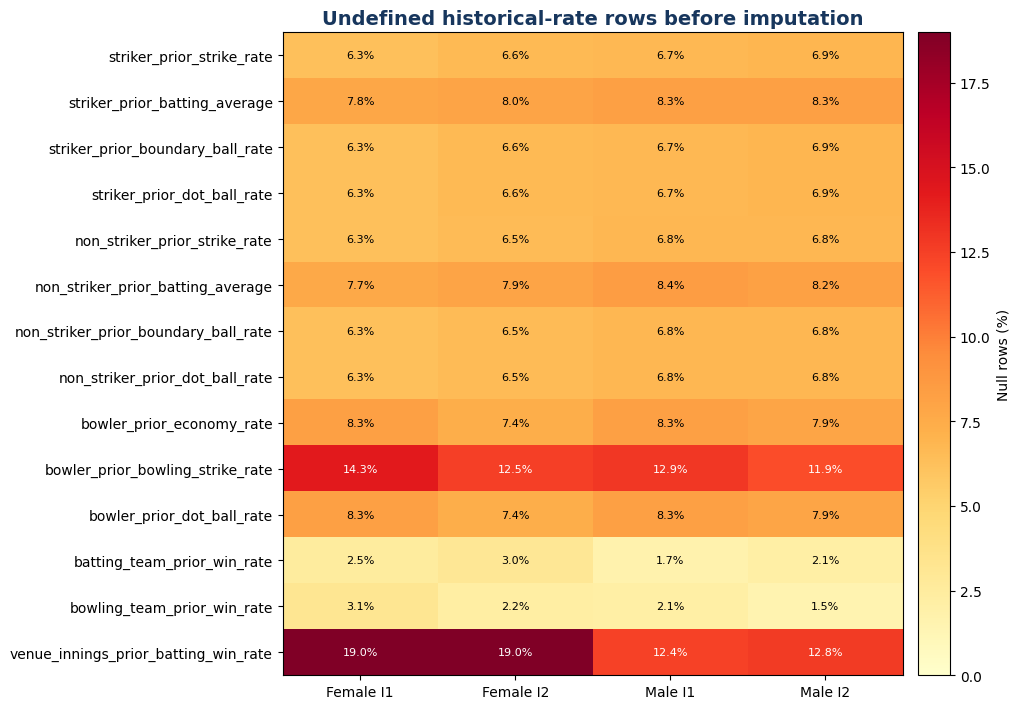

In [6]:
import matplotlib.pyplot as plt

NAVY = '#17365D'
track_labels = ['Female I1', 'Female I2', 'Male I1', 'Male I2']
null_percent = pd.DataFrame({
    track_name: {
        feature: 100 * count / track_metrics[track_name]['rows']
        for feature, count in track_metrics[track_name]['historical_feature_nulls'].items()
    }
    for track_name in TRACK_NAMES
})
null_percent = null_percent.loc[null_percent.max(axis=1).gt(0)]

fig, ax = plt.subplots(figsize=(10.5, 7.2))
image = ax.imshow(null_percent.to_numpy(), aspect='auto', cmap='YlOrRd', vmin=0, vmax=null_percent.to_numpy().max())
ax.set_xticks(range(len(track_labels)), labels=track_labels)
ax.set_yticks(range(len(null_percent.index)), labels=null_percent.index)
ax.set_title('Undefined historical-rate rows before imputation', fontsize=14, fontweight='bold', color=NAVY)
for row in range(null_percent.shape[0]):
    for column in range(null_percent.shape[1]):
        value = null_percent.iloc[row, column]
        ax.text(column, row, f'{value:.1f}%', ha='center', va='center', color='black' if value < null_percent.to_numpy().max() * 0.62 else 'white', fontsize=8)
cbar = fig.colorbar(image, ax=ax, pad=0.02)
cbar.set_label('Null rows (%)')
fig.tight_layout()
plt.show()

## 4. Save compact Phase 03 metrics

The report records the exact predictor contract, null/exposure behavior, identity limitation, and leakage checks. Multi-team display names are a diagnostic, not automatically a data error: they may represent genuine dual-national players or unresolved name collisions.

In [7]:
phase_03_metrics = {
    'report_version': 1,
    'source': {
        'phase_02_metrics_path': str(PHASE_02_METRICS_PATH.relative_to(PROJECT_ROOT)),
        'rows': int(len(events)),
        'matches': int(events['match_id'].nunique()),
    },
    'history_policy': {
        'date_rule': HISTORY_CONFIG['date_rule'],
        'equal_date_rule': HISTORY_CONFIG['equal_date_rule'],
        'player_identity': HISTORY_CONFIG['player_identity'],
        'fallback': HISTORY_CONFIG['undefined_rate_policy'],
        'playing_xi_inferred': False,
        'player_history_crosses_innings': True,
        'team_history_crosses_innings': True,
        'venue_history_grouping': ['gender', 'venue', 'match_innings'],
    },
    'historical_model_feature_columns': HISTORICAL_MODEL_FEATURES,
    'definitions': {
        'batting_ball': HISTORY_CONFIG['batting_ball_definition'],
        'batting_dot_ball': HISTORY_CONFIG['batting_dot_definition'],
        'boundary_ball': HISTORY_CONFIG['boundary_ball_definition'],
        'bowler_runs_conceded_exclusions': HISTORY_CONFIG['bowler_runs_conceded_exclusions'],
        'bowler_wicket_exclusions': sorted(non_bowler_wickets),
    },
    'lookups': {
        'batting_player_dates': int(len(batting_prior)),
        'bowling_player_dates': int(len(bowling_prior)),
        'team_dates': int(len(team_prior)),
        'venue_innings_dates': int(len(venue_prior)),
    },
    'identity_diagnostics': {
        'exact_player_names_associated_with_multiple_batting_teams': multi_team_player_names,
    },
    'quality_checks': {
        'synthetic_equal_date_isolation_passed': True,
        'first_observation_nonzero_prior_count': first_observation_nonzero_prior_count,
        'duplicate_output_header_count': duplicate_output_header_count,
        'history_count_null_rows': history_count_null_rows,
        'bounded_rate_out_of_range_rows': bounded_rate_out_of_range_rows,
        'nonnegative_rate_violation_rows': nonnegative_rate_violation_rows,
        'four_track_row_reconciliation': int(total_output_rows),
    },
    'tracks': track_metrics,
}

METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.write_text(json.dumps(phase_03_metrics, indent=2, sort_keys=True) + '\n')

display(pd.DataFrame([
    {
        'track': name,
        'rows': values['rows'],
        'matches': values['matches'],
        'columns': values['columns'],
    }
    for name, values in track_metrics.items()
]))
print(f'Phase 03 metrics: {METRICS_PATH.relative_to(PROJECT_ROOT)}')

,track,rows,matches,columns
0,female_innings_1,235716,1871,63
1,female_innings_2,200554,1871,68
2,male_innings_1,382777,3104,63
3,male_innings_2,337168,3104,68


Phase 03 metrics: reports/metrics/phase_03_historical_features.json


## Phase-03 conclusion

The four Phase 03 files preserve the Phase 02 delivery rows and innings-specific schemas while adding 23 strictly prior-date historical predictors. Phase 04 may now create equal-date chronological splits, fit all imputers/encoders on training data only, add explicit pre-innings states, and compare candidate models.